<a href="https://colab.research.google.com/github/marukomets/ec_retail_colab/blob/main/ec_retail_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EC売上分析ポートフォリオ

## このノートブックでやっていること
- 公式配布の EC 取引データを直接取得する
- 売上分析に使うべき取引だけを残すための前処理を行う
- 月次売上、国別売上、商品売上から全体像を確認する
- RFM 分析で顧客価値を分類する
- コホート分析で継続率を確認する
- AI モデルで翌月再購買を予測する
- XAI でモデルの判断根拠を説明する
- 差の差分析で年末需要の追加効果を近似する
- 最後に施策案と分析上の限界を整理する

## 分析の問い
- 売上はいつ伸びるのか
- どの国とどの顧客群が売上を支えているのか
- 初回購入後に継続しやすいのか
- どの顧客が翌月再購買しそうか
- どの顧客にどんな再購買施策を打つべきか

## 使用データ
- データ名: Online Retail
- 配布元: UCI Machine Learning Repository
- 期間: 2010-12-01 から 2011-12-09
- レコード数: 541,909
- 主な列: InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, Country

## 確からしさの見方
- 前処理前後の件数を表示して、何を除外したかを明示する
- 売上や継続率の定義を各セクションで固定する
- 同じ公式データ URL から再実行できるようにする
- AI モデルは時系列で holdout を分けて評価する
- XAI は特徴量重要度と部分依存で説明する
- 施策案は集計結果とセグメント定義に対応づけて説明する


In [ ]:
%pip -q install openpyxl seaborn plotly statsmodels scikit-learn

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay, partial_dependence, permutation_importance
from sklearn.metrics import average_precision_score, roc_auc_score

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.2f}".format)
sns.set_theme(style="whitegrid", context="talk")
warnings.filterwarnings("ignore")

DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"


In [ ]:
raw_df = pd.read_excel(DATA_URL)

print(f"raw shape: {raw_df.shape}")
display(raw_df.head())
display(raw_df.isna().sum().to_frame("missing_count"))


raw shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.00,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.00,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom


,missing_count
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


## 1. 前処理

このデータでは、`InvoiceNo` が `C` で始まるレコードはキャンセルです。売上分析では通常購入だけを対象にし、さらに以下を除外します。

- `CustomerID` が欠損している行
- `Quantity <= 0`
- `UnitPrice <= 0`

前処理の理由は、売上を生まない履歴や顧客単位で追跡できない履歴を混ぜると、RFM と継続率の解釈が崩れるためです。

## この章で確認したいこと
- どの条件で何件除外したか
- 最終的に分析対象が何行残ったか
- 売上列 `Sales` が一貫した定義で計算されているか


In [ ]:
df = raw_df.rename(columns=str.strip).copy()
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["is_cancelled"] = df["InvoiceNo"].astype(str).str.startswith("C")
df["Sales"] = df["Quantity"] * df["UnitPrice"]

quality_summary = pd.DataFrame(
    {
        "metric": [
            "raw_rows",
            "missing_customer_rows",
            "cancelled_rows",
            "non_positive_quantity_rows",
            "non_positive_price_rows",
        ],
        "value": [
            len(df),
            int(df["CustomerID"].isna().sum()),
            int(df["is_cancelled"].sum()),
            int((df["Quantity"] <= 0).sum()),
            int((df["UnitPrice"] <= 0).sum()),
        ],
    }
)
display(quality_summary)

analysis_df = df.loc[
    (~df["is_cancelled"])
    & df["CustomerID"].notna()
    & (df["Quantity"] > 0)
    & (df["UnitPrice"] > 0)
].copy()

analysis_df["CustomerID"] = analysis_df["CustomerID"].astype("int64")
analysis_df["invoice_month"] = analysis_df["InvoiceDate"].dt.to_period("M").dt.to_timestamp()
analysis_df["Sales"] = analysis_df["Quantity"] * analysis_df["UnitPrice"]

print(f"analysis shape: {analysis_df.shape}")
display(analysis_df.head())


,metric,value
0,raw_rows,541909
1,missing_customer_rows,135080
2,cancelled_rows,9288
3,non_positive_quantity_rows,10624
4,non_positive_price_rows,2517


analysis shape: (397884, 11)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,is_cancelled,Sales,invoice_month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,False,15.30,2010-12-01
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34,2010-12-01
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,False,22.00,2010-12-01
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34,2010-12-01
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34,2010-12-01


## 2. 売上の全体像

ここでは、月次売上、国別売上、商品別売上をざっくり確認します。採用担当や閲覧者は、最初にこの全体像があると分析テーマを理解しやすくなります。

## この章でやっていること
- 月ごとの売上、受注数、顧客数を集計する
- 売上の大きい国を確認して、主要マーケットを把握する
- 売上上位商品を見て、商品構成の偏りを確認する

この段階では因果関係を主張せず、まず事実としての分布と波形を押さえます。


In [ ]:
monthly_sales = (
    analysis_df.groupby("invoice_month")
    .agg(
        sales=("Sales", "sum"),
        orders=("InvoiceNo", "nunique"),
        customers=("CustomerID", "nunique"),
    )
    .reset_index()
)
monthly_sales["aov"] = monthly_sales["sales"] / monthly_sales["orders"]
display(monthly_sales)

fig = px.line(
    monthly_sales,
    x="invoice_month",
    y="sales",
    markers=True,
    title="月次売上の推移",
    labels={"invoice_month": "月", "sales": "売上"},
)
fig.show()

country_sales = (
    analysis_df.groupby("Country")
    .agg(sales=("Sales", "sum"), customers=("CustomerID", "nunique"))
    .sort_values("sales", ascending=False)
    .head(10)
    .reset_index()
)
display(country_sales)

fig = px.bar(
    country_sales,
    x="Country",
    y="sales",
    color="customers",
    title="国別売上 Top 10",
    labels={"sales": "売上", "customers": "顧客数"},
)
fig.show()

product_sales = (
    analysis_df.groupby("Description")
    .agg(sales=("Sales", "sum"), quantity=("Quantity", "sum"))
    .sort_values("sales", ascending=False)
    .head(10)
    .reset_index()
)
display(product_sales)


,invoice_month,sales,orders,customers,aov
0,2010-12-01,572713.89,1400,885,409.08
1,2011-01-01,569445.04,987,741,576.95
2,2011-02-01,447137.35,997,758,448.48
3,2011-03-01,595500.76,1321,974,450.80
4,2011-04-01,469200.36,1149,856,408.36
5,2011-05-01,678594.56,1555,1056,436.40
6,2011-06-01,661213.69,1393,991,474.67
7,2011-07-01,600091.01,1331,949,450.86
8,2011-08-01,645343.90,1280,935,504.17
9,2011-09-01,952838.38,1755,1266,542.93


,Country,sales,customers
0,United Kingdom,7308391.55,3920
1,Netherlands,285446.34,9
2,EIRE,265545.90,3
3,Germany,228867.14,94
4,France,209024.05,87
5,Australia,138521.31,9
6,Spain,61577.11,30
7,Switzerland,56443.95,21
8,Belgium,41196.34,25
9,Sweden,38378.33,8


,Description,sales,quantity
0,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995
1,REGENCY CAKESTAND 3 TIER,142592.95,12402
2,WHITE HANGING HEART T-LIGHT HOLDER,100448.15,36725
3,JUMBO BAG RED RETROSPOT,85220.78,46181
4,MEDIUM CERAMIC TOP STORAGE JAR,81416.73,77916
5,POSTAGE,77803.96,3120
6,PARTY BUNTING,68844.33,15291
7,ASSORTED COLOUR BIRD ORNAMENT,56580.34,35362
8,Manual,53779.93,7173
9,RABBIT NIGHT LIGHT,51346.20,27202


## 3. RFM分析

RFM は、顧客価値を `Recency` `Frequency` `Monetary` の 3 軸でみる定番分析です。このノートブックでは、優良顧客だけでなく、再アプローチ対象も把握できるようにしています。

## RFM の定義
- Recency: 最終購入日からの経過日数。小さいほど良い
- Frequency: 何回注文したか。大きいほど良い
- Monetary: いくら売上を作ったか。大きいほど良い

## この章での検証観点
- スコア計算をルールベースで固定して再現可能にする
- 同点が多い列でも `rank` を使って分位分割できるようにする
- セグメント名と施策の対応が説明できる形にする


In [ ]:
snapshot_date = analysis_df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = analysis_df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("Sales", "sum"),
)

rfm["R_score"] = pd.qcut(rfm["Recency"].rank(method="first"), 4, labels=[4, 3, 2, 1]).astype(int)
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
rfm["M_score"] = pd.qcut(rfm["Monetary"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
rfm["RFM_Score"] = rfm[["R_score", "F_score", "M_score"]].sum(axis=1)

def assign_segment(row):
    if row["R_score"] >= 4 and row["F_score"] >= 4 and row["M_score"] >= 4:
        return "Champions"
    if row["R_score"] >= 3 and row["F_score"] >= 3 and row["M_score"] >= 3:
        return "Loyal Customers"
    if row["R_score"] == 4 and row["F_score"] <= 2:
        return "Promising"
    if row["R_score"] <= 2 and row["F_score"] >= 3:
        return "At Risk"
    return "Needs Attention"

rfm["Segment"] = rfm.apply(assign_segment, axis=1)

segment_summary = (
    rfm.groupby("Segment")
    .agg(
        customers=("Segment", "size"),
        avg_recency=("Recency", "mean"),
        avg_frequency=("Frequency", "mean"),
        avg_monetary=("Monetary", "mean"),
    )
    .sort_values("avg_monetary", ascending=False)
    .reset_index()
)
display(segment_summary)

fig = px.bar(
    segment_summary,
    x="Segment",
    y="customers",
    color="avg_monetary",
    title="顧客セグメント別の人数と平均売上",
    labels={"customers": "顧客数", "avg_monetary": "平均売上"},
)
fig.show()

display(rfm.sort_values(["RFM_Score", "Monetary"], ascending=False).head(10))


,Segment,customers,avg_recency,avg_frequency,avg_monetary
0,Champions,478,7.17,15.72,9190.88
1,Loyal Customers,836,22.57,5.77,2513.11
2,At Risk,655,118.26,4.18,1610.99
3,Promising,221,9.52,1.56,1276.44
4,Needs Attention,2148,139.46,1.45,502.75


,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
CustomerID,,,,,,,,
14646,2,73,280206.02,4,4,4,12,Champions
18102,1,60,259657.30,4,4,4,12,Champions
17450,8,46,194550.79,4,4,4,12,Champions
14911,1,201,143825.06,4,4,4,12,Champions
14156,10,55,117379.63,4,4,4,12,Champions
17511,3,31,91062.38,4,4,4,12,Champions
16684,4,28,66653.56,4,4,4,12,Champions
14096,4,17,65164.79,4,4,4,12,Champions
13694,4,50,65039.62,4,4,4,12,Champions


## 4. コホート分析

コホート分析では、初回購入月ごとに翌月以降の継続率を見ます。ここで継続率の弱い月や、強い獲得月があるかを確認できます。

## この章でやっていること
- 顧客ごとの初回購入月を求める
- 初回購入月から何か月後の購入かを `cohort_index` として計算する
- 初回購入月ごとに継続率を行列化し、ヒートマップで確認する

継続率は、各コホートの初月人数を分母にしているため、1 列目は 100% になるのが自然です。ここも整合性確認の観点になります。


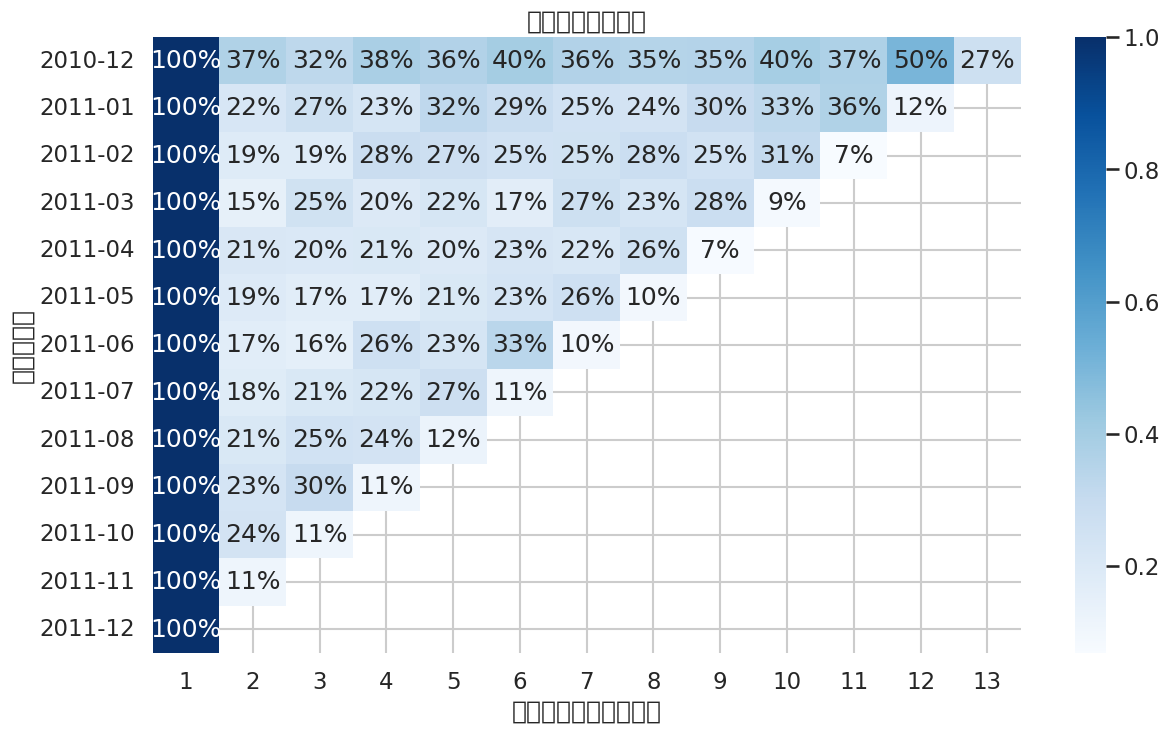

cohort_index,1,2,3,4,5,6,7,8,9,10,11,12,13
cohort_month,,,,,,,,,,,,,
2010-12,1.00,0.37,0.32,0.38,0.36,0.40,0.36,0.35,0.35,0.40,0.37,0.50,0.27
2011-01,1.00,0.22,0.27,0.23,0.32,0.29,0.25,0.24,0.30,0.33,0.36,0.12,NaN
2011-02,1.00,0.19,0.19,0.28,0.27,0.25,0.25,0.28,0.25,0.30,0.07,NaN,NaN
2011-03,1.00,0.15,0.25,0.20,0.22,0.17,0.27,0.23,0.28,0.09,NaN,NaN,NaN
2011-04,1.00,0.21,0.20,0.21,0.20,0.23,0.22,0.26,0.07,NaN,NaN,NaN,NaN
2011-05,1.00,0.19,0.17,0.17,0.21,0.23,0.26,0.10,NaN,NaN,NaN,NaN,NaN
2011-06,1.00,0.17,0.16,0.26,0.23,0.34,0.10,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,1.00,0.18,0.21,0.22,0.27,0.11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,1.00,0.21,0.25,0.24,0.12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
cohort_df = analysis_df[["CustomerID", "InvoiceDate"]].copy()
cohort_df["purchase_month"] = cohort_df["InvoiceDate"].dt.to_period("M")
cohort_df["cohort_month"] = cohort_df.groupby("CustomerID")["purchase_month"].transform("min")
cohort_df["cohort_index"] = (
    (cohort_df["purchase_month"].dt.year - cohort_df["cohort_month"].dt.year) * 12
    + (cohort_df["purchase_month"].dt.month - cohort_df["cohort_month"].dt.month)
    + 1
)

retention = (
    cohort_df.groupby(["cohort_month", "cohort_index"])["CustomerID"]
    .nunique()
    .reset_index()
)
retention_matrix = retention.pivot(index="cohort_month", columns="cohort_index", values="CustomerID")
cohort_sizes = retention_matrix.iloc[:, 0]
retention_rate = retention_matrix.divide(cohort_sizes, axis=0)

plt.figure(figsize=(14, 8))
sns.heatmap(retention_rate, annot=True, fmt=".0%", cmap="Blues")
plt.title("コホート別継続率")
plt.xlabel("初回購入からの経過月")
plt.ylabel("初回購入月")
plt.show()

display(retention_rate.round(3))


## 5. AI分析: 翌月再購買予測

ここでは、顧客が `翌月に再購買するか` を予測する AI モデルを作ります。目的は、再購入施策を全顧客に一律で配るのではなく、再購買確率が高い顧客や、逆にフォローが必要な顧客を優先的に識別することです。

## タスク定義
- 1 レコードは `顧客 × 月` のスナップショット
- 目的変数は `翌月に1回でも購入したか`
- 特徴量は、その月までに観測できる情報だけを使う
- 学習期間は 2011-08 まで、評価期間は 2011-09 と 2011-10 に固定する

## XAI の方針
- `Permutation Importance` で予測に効いた特徴量を確認する
- `Partial Dependence` で主要特徴量が予測確率にどう効くかを見る

ブラックボックスなモデルを置くのではなく、`どの特徴が効いたのか` と `その方向性` を説明可能にすることを重視します。


,metric,value,interpretation
0,Train rows,8145,学習に使った顧客月サンプル数。
1,Test rows,2630,将来時点の holdout 評価サンプル数。
2,Test positive rate,42.2%,何もしなくても当たるベースラインの再購買率。
3,ROC-AUC,0.736,再購買しやすい顧客を順位づけできているか。
4,PR-AUC,0.713,陽性が少ない場面でも精度を見やすい指標。
5,Precision@Top20%,81.7%,上位20%に絞ったときの当たり率。
6,Lift@Top20%,1.94x,ベースラインよりどれだけ効率よく当てられるか。


,feature,importance_mean,importance_std
9,cum_active_days,0.02,0.01
7,cum_orders,0.01,0.00
4,monthly_active_days,0.01,0.00
6,cum_sales,0.00,0.00
0,recency_days,0.00,0.00
2,monthly_orders,0.00,0.00
11,months_active,0.00,0.00
12,avg_order_value,0.00,0.00
1,monthly_sales,0.00,0.00
13,avg_units_per_order,0.00,0.00


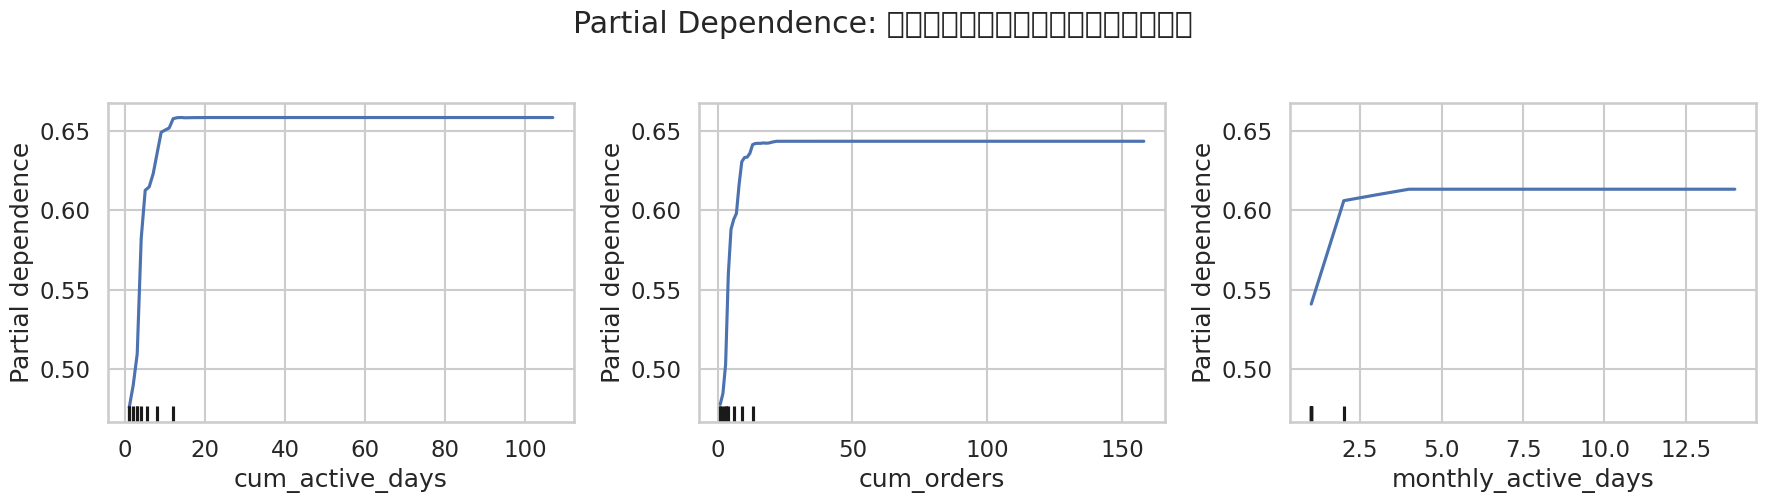

,feature,importance_mean,pdp_trend,interpretation
0,cum_active_days,0.02,up,過去の接触日数が多い顧客ほど、翌月も買う確率が高い。
1,cum_orders,0.01,up,累積注文回数が多い顧客ほど、再購買確率が上がる。
2,monthly_active_days,0.01,up,当月に複数日にわたって購入した顧客は、翌月も買いやすい。


In [ ]:
customer_month = (
    analysis_df.groupby(["CustomerID", "invoice_month"])
    .agg(
        monthly_sales=("Sales", "sum"),
        monthly_orders=("InvoiceNo", "nunique"),
        monthly_units=("Quantity", "sum"),
        monthly_active_days=("InvoiceDate", lambda x: x.dt.normalize().nunique()),
        monthly_distinct_products=("StockCode", "nunique"),
        last_purchase_in_month=("InvoiceDate", "max"),
    )
    .sort_index()
    .reset_index()
)

customer_month["month_end"] = customer_month["invoice_month"] + pd.offsets.MonthEnd(0)
customer_month["recency_days"] = (
    customer_month["month_end"] - customer_month["last_purchase_in_month"]
).dt.days
customer_month["cum_sales"] = customer_month.groupby("CustomerID")["monthly_sales"].cumsum()
customer_month["cum_orders"] = customer_month.groupby("CustomerID")["monthly_orders"].cumsum()
customer_month["cum_units"] = customer_month.groupby("CustomerID")["monthly_units"].cumsum()
customer_month["cum_active_days"] = customer_month.groupby("CustomerID")["monthly_active_days"].cumsum()
customer_month["cum_distinct_products"] = customer_month.groupby("CustomerID")["monthly_distinct_products"].cumsum()
customer_month["months_active"] = customer_month.groupby("CustomerID").cumcount() + 1
customer_month["avg_order_value"] = customer_month["cum_sales"] / customer_month["cum_orders"]
customer_month["avg_units_per_order"] = customer_month["cum_units"] / customer_month["cum_orders"]
customer_month["next_month"] = customer_month["invoice_month"] + pd.offsets.MonthBegin(1)
customer_month["repurchase_next_month"] = customer_month.set_index(
    ["CustomerID", "next_month"]
).index.isin(
    customer_month.set_index(["CustomerID", "invoice_month"]).index
).astype(int)

model_df = customer_month.loc[customer_month["invoice_month"] <= pd.Timestamp("2011-10-01")].copy()

feature_cols = [
    "recency_days",
    "monthly_sales",
    "monthly_orders",
    "monthly_units",
    "monthly_active_days",
    "monthly_distinct_products",
    "cum_sales",
    "cum_orders",
    "cum_units",
    "cum_active_days",
    "cum_distinct_products",
    "months_active",
    "avg_order_value",
    "avg_units_per_order",
]

train_df = model_df.loc[model_df["invoice_month"] < pd.Timestamp("2011-09-01")].copy()
test_df = model_df.loc[
    (model_df["invoice_month"] >= pd.Timestamp("2011-09-01"))
    & (model_df["invoice_month"] <= pd.Timestamp("2011-10-01"))
].copy()

X_train = train_df[feature_cols].astype(float)
y_train = train_df["repurchase_next_month"]
X_test = test_df[feature_cols].astype(float)
y_test = test_df["repurchase_next_month"].reset_index(drop=True)

rf_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=6,
    min_samples_leaf=20,
    random_state=42,
    class_weight="balanced",
)
rf_model.fit(X_train, y_train)

test_pred = pd.Series(rf_model.predict_proba(X_test)[:, 1], name="pred_prob")
roc_auc = roc_auc_score(y_test, test_pred)
pr_auc = average_precision_score(y_test, test_pred)

ranked_test = test_df[["CustomerID", "invoice_month"]].reset_index(drop=True).copy()
ranked_test["target"] = y_test
ranked_test["pred_prob"] = test_pred
ranked_test = ranked_test.sort_values("pred_prob", ascending=False).reset_index(drop=True)
top_k = max(1, int(len(ranked_test) * 0.2))
precision_top20 = ranked_test.loc[: top_k - 1, "target"].mean()
base_rate = ranked_test["target"].mean()
lift_top20 = precision_top20 / base_rate

model_summary = pd.DataFrame(
    {
        "metric": [
            "Train rows",
            "Test rows",
            "Test positive rate",
            "ROC-AUC",
            "PR-AUC",
            "Precision@Top20%",
            "Lift@Top20%",
        ],
        "value": [
            len(train_df),
            len(test_df),
            f"{base_rate:.1%}",
            f"{roc_auc:.3f}",
            f"{pr_auc:.3f}",
            f"{precision_top20:.1%}",
            f"{lift_top20:.2f}x",
        ],
        "interpretation": [
            "学習に使った顧客月サンプル数。",
            "将来時点の holdout 評価サンプル数。",
            "何もしなくても当たるベースラインの再購買率。",
            "再購買しやすい顧客を順位づけできているか。",
            "陽性が少ない場面でも精度を見やすい指標。",
            "上位20%に絞ったときの当たり率。",
            "ベースラインよりどれだけ効率よく当てられるか。",
        ],
    }
)
display(model_summary)

perm = permutation_importance(
    rf_model,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring="roc_auc",
)
importance_df = pd.DataFrame(
    {
        "feature": feature_cols,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    }
).sort_values("importance_mean", ascending=False)
display(importance_df.head(10))

fig = px.bar(
    importance_df.head(8),
    x="importance_mean",
    y="feature",
    error_x="importance_std",
    orientation="h",
    title="Permutation Importance 上位特徴量",
    labels={"importance_mean": "重要度", "feature": "特徴量"},
)
fig.update_layout(yaxis={"categoryorder": "total ascending"})
fig.show()

pdp_features = ["cum_active_days", "cum_orders", "monthly_active_days"]
fig, axes = plt.subplots(1, len(pdp_features), figsize=(18, 5))
PartialDependenceDisplay.from_estimator(
    rf_model,
    X_test,
    features=pdp_features,
    ax=axes,
)
plt.suptitle("Partial Dependence: 主要特徴量が再購買確率に与える影響", y=1.02)
plt.tight_layout()
plt.show()

xai_rows = []
xai_message = {
    "cum_active_days": "過去の接触日数が多い顧客ほど、翌月も買う確率が高い。",
    "cum_orders": "累積注文回数が多い顧客ほど、再購買確率が上がる。",
    "monthly_active_days": "当月に複数日にわたって購入した顧客は、翌月も買いやすい。",
}
for feat in pdp_features:
    pdp_result = partial_dependence(rf_model, X_test, [feat], kind="average", grid_resolution=20)
    trend = "up" if pdp_result["average"][0][-1] > pdp_result["average"][0][0] else "down"
    xai_rows.append(
        {
            "feature": feat,
            "importance_mean": importance_df.set_index("feature").loc[feat, "importance_mean"],
            "pdp_trend": trend,
            "interpretation": xai_message[feat],
        }
    )
xai_summary = pd.DataFrame(xai_rows).sort_values("importance_mean", ascending=False)
display(xai_summary)


## 6. 準因果分析: 年末商戦は季節商材の売上を押し上げたか

このデータだけで厳密な因果効果を断定することはできませんが、`季節商材` を処置群、`非季節商材` を対照群とみなし、`2011-09-01` 以降を介入後とする差の差分析を行います。

## 設計の考え方
- 処置群: 商品名に `CHRISTMAS` `PARTY` `GIFT` `DECORATION` `WRAP` `CARD` `BUNTING` を含む季節商材
- 対照群: それ以外の非季節商材
- 介入後: 2011-09-01 から 2011-11-30 まで
- 目的: 年末期が季節商材にだけ追加的な売上押し上げを与えたかを見る

## 識別の前提
- 介入がなければ、季節商材と非季節商材の売上差は大きくは乖離しない
- 年末期以外の一時的ショックは、両群に同程度に作用する

この前提は証明できないため、ここでは `placebo test` として 2011-06-01 を擬似介入日に置いた差の差も確認します。placebo で効果が強く出ないことを、最低限の整合性確認に使います。


In [ ]:
did_df = analysis_df.copy()
did_df["date"] = did_df["InvoiceDate"].dt.normalize()
did_df = did_df.loc[(did_df["date"] >= "2011-01-01") & (did_df["date"] < "2011-12-01")].copy()
did_df["seasonal_flag"] = did_df["Description"].astype(str).str.contains(
    "CHRISTMAS|PARTY|GIFT|DECORATION|WRAP|CARD|BUNTING",
    case=False,
    na=False,
).astype(int)
did_df["post_holiday"] = (did_df["date"] >= "2011-09-01").astype(int)
did_df["dow"] = did_df["date"].dt.dayofweek.astype(str)

did_daily = (
    did_df.groupby(["date", "seasonal_flag", "post_holiday", "dow"], as_index=False)
    .agg(sales=("Sales", "sum"), orders=("InvoiceNo", "nunique"))
)
did_daily["log_sales"] = np.log1p(did_daily["sales"])

did_model = smf.ols(
    "log_sales ~ seasonal_flag + post_holiday + seasonal_flag:post_holiday + C(dow)",
    data=did_daily,
).fit(cov_type="HC3")

did_coef = did_model.params["seasonal_flag:post_holiday"]
did_pvalue = did_model.pvalues["seasonal_flag:post_holiday"]
did_ci_low, did_ci_high = did_model.conf_int().loc["seasonal_flag:post_holiday"]
did_effect = np.expm1(did_coef)
did_effect_low = np.expm1(did_ci_low)
did_effect_high = np.expm1(did_ci_high)

placebo_df = did_df.loc[did_df["date"] < "2011-09-01"].copy()
placebo_df["placebo_post"] = (placebo_df["date"] >= "2011-06-01").astype(int)
placebo_daily = (
    placebo_df.groupby(["date", "seasonal_flag", "placebo_post", "dow"], as_index=False)
    .agg(sales=("Sales", "sum"))
)
placebo_daily["log_sales"] = np.log1p(placebo_daily["sales"])
placebo_model = smf.ols(
    "log_sales ~ seasonal_flag + placebo_post + seasonal_flag:placebo_post + C(dow)",
    data=placebo_daily,
).fit(cov_type="HC3")
placebo_coef = placebo_model.params["seasonal_flag:placebo_post"]
placebo_pvalue = placebo_model.pvalues["seasonal_flag:placebo_post"]

# Fix: Create a temporary column for the month period before grouping
did_df['invoice_month_period'] = did_df["date"].dt.to_period("M")
monthly_did = (
    did_df.groupby(["invoice_month_period", "seasonal_flag"], as_index=False)
    .agg(sales=("Sales", "sum"))
)
monthly_did["month"] = monthly_did["invoice_month_period"].astype(str)
monthly_did["group"] = np.where(monthly_did["seasonal_flag"] == 1, "Seasonal Items", "Non-seasonal Items")

causal_summary = pd.DataFrame(
    {
        "metric": [
            "差の差の追加効果",
            "95% 信頼区間",
            "p値",
            "placebo の追加効果",
            "placebo の p値",
        ],
        "value": [
            f"{did_effect:.1%}",
            f"{did_effect_low:.1%} から {did_effect_high:.1%}",
            f"{did_pvalue:.3g}",
            f"{np.expm1(placebo_coef):.1%}",
            f"{placebo_pvalue:.3g}",
        ],
        "interpretation": [
            "年末期は、非季節商材に対して季節商材の売上を追加的に押し上げた可能性がある。",
            "効果の大きさには幅があるが、正の効果が示唆される。",
            "統計的には有意である。",
            "擬似介入では効果はかなり小さくなる。",
            "擬似介入では有意でなく、少なくとも常に同じ効果が出る仕様ではない。",
        ],
    }
)
display(causal_summary)

did_params = pd.DataFrame(
    {
        "coef": did_model.params,
        "pvalue": did_model.pvalues,
        "ci_low": did_model.conf_int()[0],
        "ci_high": did_model.conf_int()[1],
    }
)
display(did_params.loc[["seasonal_flag", "post_holiday", "seasonal_flag:post_holiday"]])

fig = px.line(
    monthly_did,
    x="month",
    y="sales",
    color="group",
    markers=True,
    title="季節商材と非季節商材の月次売上",
    labels={"month": "月", "sales": "売上", "group": "商品群"},
)
fig.show()

,metric,value,interpretation
0,差の差の追加効果,75.5%,年末期は、非季節商材に対して季節商材の売上を追加的に押し上げた可能性がある。
1,95% 信頼区間,51.2% から 103.7%,効果の大きさには幅があるが、正の効果が示唆される。
2,p値,1.38e-13,統計的には有意である。
3,placebo の追加効果,14.6%,擬似介入では効果はかなり小さくなる。
4,placebo の p値,0.144,擬似介入では有意でなく、少なくとも常に同じ効果が出る仕様ではない。


,coef,pvalue,ci_low,ci_high
seasonal_flag,-2.30,0.00,-2.39,-2.21
post_holiday,0.52,0.00,0.42,0.62
seasonal_flag:post_holiday,0.56,0.00,0.41,0.71


## 7. 結果の解釈と打ち手

このセクションでは、`どの数値から、どんな判断につなげたか` が読み取れるように、結果を根拠つきで整理します。ポートフォリオとしては、グラフを並べるだけでなく、判断の筋道まで説明できることが重要です。

## この章で見るポイント
- AI モデルがどの程度、再購買候補を絞り込めたか
- 準因果分析でどの程度の追加効果が見えたか
- 売上がどこに集中しているか
- 年末の売上増がどんな商品傾向と結びついているか
- 少数の優良顧客にどれだけ依存しているか
- どの顧客層を優先的に引き上げるべきか

## 確からしさをどう検証しているか
- データ取得元は UCI の公式 URL に固定している
- 前処理前後の件数を `quality_summary` と `analysis shape` で確認している
- 売上指標は `Quantity * UnitPrice` で一貫して計算している
- RFM は明示的なルールでスコア化しているため再現可能である
- コホート分析は初回購入月を基準にしており、継続率の分母が明確である
- AI モデルは未来情報を混ぜない時系列 holdout で評価している
- XAI は特徴量重要度と部分依存で確認している

## この分析の限界
- 単一企業の履歴データなので、他業種にそのまま一般化はできない
- 利益や原価がないため、評価は売上ベースである
- AI モデルの予測対象は翌月再購買に限られ、長期LTVまでは直接扱っていない
- 差の差分析は準実験であり、厳密なランダム化実験ではない
- 季節商材の定義は商品名ベースのルールであり、分類誤差を含む可能性がある


In [ ]:
country_share = (
    analysis_df.groupby("Country")
    .agg(sales=("Sales", "sum"), customers=("CustomerID", "nunique"))
    .sort_values("sales", ascending=False)
    .reset_index()
)
country_share["sales_share"] = country_share["sales"] / country_share["sales"].sum()

segment_diagnostic = (
    rfm.groupby("Segment")
    .agg(
        customers=("Segment", "size"),
        revenue=("Monetary", "sum"),
        avg_recency=("Recency", "mean"),
        avg_frequency=("Frequency", "mean"),
        avg_monetary=("Monetary", "mean"),
    )
    .reset_index()
)
segment_diagnostic["customer_share"] = segment_diagnostic["customers"] / segment_diagnostic["customers"].sum()
segment_diagnostic["revenue_share"] = segment_diagnostic["revenue"] / segment_diagnostic["revenue"].sum()

segment_order = (
    analysis_df.merge(rfm[["Segment"]], left_on="CustomerID", right_index=True)
    .groupby("Segment")
    .agg(orders=("InvoiceNo", "nunique"), sales=("Sales", "sum"), units=("Quantity", "sum"))
    .reset_index()
)
segment_order["aov"] = segment_order["sales"] / segment_order["orders"]
segment_order["units_per_order"] = segment_order["units"] / segment_order["orders"]

seasonal_df = analysis_df.copy()
seasonal_df["seasonal_sales"] = np.where(
    seasonal_df["Description"].astype(str).str.contains(
        "CHRISTMAS|PARTY|GIFT|DECORATION|WRAP|CARD|BUNTING",
        case=False,
        na=False,
    ),
    seasonal_df["Sales"],
    0,
)
seasonal_monthly = (
    seasonal_df.groupby("invoice_month")
    .agg(total_sales=("Sales", "sum"), seasonal_sales=("seasonal_sales", "sum"))
    .reset_index()
)
seasonal_monthly["seasonal_ratio"] = seasonal_monthly["seasonal_sales"] / seasonal_monthly["total_sales"]

mean_retention = retention_rate.mean().dropna()
next_month_retention = mean_retention.get(2, np.nan)
sep_nov_share = monthly_sales.loc[
    monthly_sales["invoice_month"].dt.month.isin([9, 10, 11]), "sales"
].sum() / monthly_sales["sales"].sum()

champions_row = segment_diagnostic.loc[segment_diagnostic["Segment"] == "Champions"].iloc[0]
at_risk_row = segment_diagnostic.loc[segment_diagnostic["Segment"] == "At Risk"].iloc[0]
promising_order_row = segment_order.loc[segment_order["Segment"] == "Promising"].iloc[0]
largest_country = country_share.iloc[0]
seasonal_peak = seasonal_monthly.sort_values("seasonal_ratio", ascending=False).iloc[0]

diagnostic_summary = pd.DataFrame(
    {
        "finding": [
            "AI モデルで翌月再購買候補を絞り込める",
            "準因果推定では年末期が季節商材売上を追加的に押し上げている",
            "売上は英国に強く集中している",
            "年末商戦の山は9月から前倒しで立ち上がっている",
            "売上は少数の優良顧客に大きく依存している",
            "失注しかけた既存顧客の掘り起こし余地が大きい",
            "初回購入後の翌月継続が最大のボトルネックである",
        ],
        "evidence": [
            f"ROC-AUC は {roc_auc:.3f}、Top20% の Precision は {precision_top20:.1%}、Lift は {lift_top20:.2f}x。",
            f"差の差分析では季節商材×9月以降の追加効果は {did_effect:.1%}、p値は {did_pvalue:.3g}。placebo の p値は {placebo_pvalue:.3g}。",
            f"{largest_country['Country']} が売上の {largest_country['sales_share']:.1%} を占める。",
            f"9-11月の売上が全体の {sep_nov_share:.1%}。季節商材比率は {seasonal_peak['invoice_month'].strftime('%Y-%m')} に {seasonal_peak['seasonal_ratio']:.1%} で最大。",
            f"Champions は顧客全体の {champions_row['customer_share']:.1%} だが、売上の {champions_row['revenue_share']:.1%} を占める。",
            f"At Risk は顧客全体の {at_risk_row['customer_share']:.1%}、売上の {at_risk_row['revenue_share']:.1%} を占める。完全離脱前に戻す価値が高い。",
            f"平均翌月継続率は {next_month_retention:.1%} にとどまる。初回購入後の早期離脱が大きい。",
        ],
        "business_interpretation": [
            "再購入施策は全件一律ではなく、高確率層を優先すると配信効率を上げられる。",
            "年末需要向け販促は実際に季節商材へ上乗せ効果を持つ可能性が高く、秋口からの投下に根拠がある。",
            "まず英国市場での販促、物流、品揃え最適化が最優先である。",
            "クリスマス関連の需要は12月だけでなく秋から立ち上がるため、仕入れと販促の前倒しが必要である。",
            "上位顧客の維持が売上防衛の中心課題であり、VIP向け施策の費用対効果が高い。",
            "休眠寸前だが購買実績のある顧客は、新規獲得より低コストで再活性化できる可能性がある。",
            "新規獲得だけではなく、初回購入から30日以内の再接触設計が必要である。",
        ],
    }
)
display(diagnostic_summary)

share_plot = segment_diagnostic.melt(
    id_vars="Segment",
    value_vars=["customer_share", "revenue_share"],
    var_name="share_type",
    value_name="share",
)
fig = px.bar(
    share_plot,
    x="Segment",
    y="share",
    color="share_type",
    barmode="group",
    title="顧客構成比と売上構成比の比較",
    labels={"share": "構成比", "share_type": "指標"},
)
fig.show()

action_plan = pd.DataFrame(
    {
        "target": [
            "AI 高確率層",
            "Champions",
            "At Risk",
            "Promising",
            "初回購入者全体",
        ],
        "reason": [
            f"Top20% に絞ると再購買率は {precision_top20:.1%} で、全体平均の {lift_top20:.2f} 倍。",
            f"少数顧客で売上の {champions_row['revenue_share']:.1%} を支えている。",
            f"既存売上の {at_risk_row['revenue_share']:.1%} を占めており、離脱コストが大きい。",
            f"Promising の平均注文単価は {promising_order_row['aov']:.0f} と高い。育成余地がある。",
            f"翌月継続率が {next_month_retention:.1%} と低く、最初の再購入導線が弱い。",
        ],
        "recommended_action": [
            "レコメンドメール、カゴ落ち再訴求、季節商材の優先配信を高確率層に集中する。",
            "限定オファー、先行案内、まとめ買い提案で離反を防ぐ。",
            "休眠前リマインド、再訪クーポン、閲覧商品ベースのメール配信を行う。",
            "2回目購入を促すセット提案やクロスセルを早めに出す。",
            "初回購入から30日以内に再購入インセンティブを自動配信する。",
        ],
        "kpi": [
            "Precision@Top20%、クリック率、再購買率",
            "上位顧客維持率、VIP 売上比率",
            "再活性化率、休眠復帰売上",
            "2回目購入率、平均注文単価",
            "翌月継続率、初回から2回目までの日数",
        ],
    }
)
display(action_plan)


,finding,evidence,business_interpretation
0,AI モデルで翌月再購買候補を絞り込める,ROC-AUC は 0.736、Top20% の Precision は 81.7%、Lif...,再購入施策は全件一律ではなく、高確率層を優先すると配信効率を上げられる。
1,準因果推定では年末期が季節商材売上を追加的に押し上げている,差の差分析では季節商材×9月以降の追加効果は 75.5%、p値は 1.38e-13。plac...,年末需要向け販促は実際に季節商材へ上乗せ効果を持つ可能性が高く、秋口からの投下に根拠がある。
2,売上は英国に強く集中している,United Kingdom が売上の 82.0% を占める。,まず英国市場での販促、物流、品揃え最適化が最優先である。
3,年末商戦の山は9月から前倒しで立ち上がっている,9-11月の売上が全体の 35.4%。季節商材比率は 2011-11 に 15.5% で最大。,クリスマス関連の需要は12月だけでなく秋から立ち上がるため、仕入れと販促の前倒しが必要である。
4,売上は少数の優良顧客に大きく依存している,Champions は顧客全体の 11.0% だが、売上の 49.3% を占める。,上位顧客の維持が売上防衛の中心課題であり、VIP向け施策の費用対効果が高い。
5,失注しかけた既存顧客の掘り起こし余地が大きい,At Risk は顧客全体の 15.1%、売上の 11.8% を占める。完全離脱前に戻す価値...,休眠寸前だが購買実績のある顧客は、新規獲得より低コストで再活性化できる可能性がある。
6,初回購入後の翌月継続が最大のボトルネックである,平均翌月継続率は 20.6% にとどまる。初回購入後の早期離脱が大きい。,新規獲得だけではなく、初回購入から30日以内の再接触設計が必要である。


,target,reason,recommended_action,kpi
0,AI 高確率層,Top20% に絞ると再購買率は 81.7% で、全体平均の 1.94 倍。,レコメンドメール、カゴ落ち再訴求、季節商材の優先配信を高確率層に集中する。,Precision@Top20%、クリック率、再購買率
1,Champions,少数顧客で売上の 49.3% を支えている。,限定オファー、先行案内、まとめ買い提案で離反を防ぐ。,上位顧客維持率、VIP 売上比率
2,At Risk,既存売上の 11.8% を占めており、離脱コストが大きい。,休眠前リマインド、再訪クーポン、閲覧商品ベースのメール配信を行う。,再活性化率、休眠復帰売上
3,Promising,Promising の平均注文単価は 818 と高い。育成余地がある。,2回目購入を促すセット提案やクロスセルを早めに出す。,2回目購入率、平均注文単価
4,初回購入者全体,翌月継続率が 20.6% と低く、最初の再購入導線が弱い。,初回購入から30日以内に再購入インセンティブを自動配信する。,翌月継続率、初回から2回目までの日数


## 提出時のひとこと例

> UCI の EC 取引データを用いて、前処理、売上推移の可視化、RFM 分析、コホート分析、翌月再購買予測、差の差による準因果分析まで一貫して実施しました。AI モデルは holdout で評価し、Permutation Importance と Partial Dependence で判断根拠も説明しています。最後の章では、AI と準因果の結果をつないで、どの顧客層に何を打つべきかを数値ベースで整理しています。
